# Perceptron

## Single Perceptron
This is a simple Rosenblatt's 1957 Algorithm. The first demonstration that a simple machine could learn from examples without beign explicitly programmed. At its core, a perceptron is a mathematical model of a biological neuron, deliberately simplified and abstracted to capture the essence of how a neuron decides to "fire". A single perceptron can learn any linearly separable pattern.

Core Concepts:
1. It's a Function of weighted sum:( $z = w_1x_1+w_2x_2+...+w_nx_n+b$ )
2. It makes a binary decision via a threshold (activation function)
3. It's a linear classifier. It divides the world of possible input patterns into two categories: yes/no decision boundary

In [56]:
from sklearn.datasets import make_blobs, load_wine

X, y= make_blobs(n_samples=200, centers=2, random_state=42)


Dataset shape: (200, 2)
Unique labels: [-1  1]
Converged at epoch 2


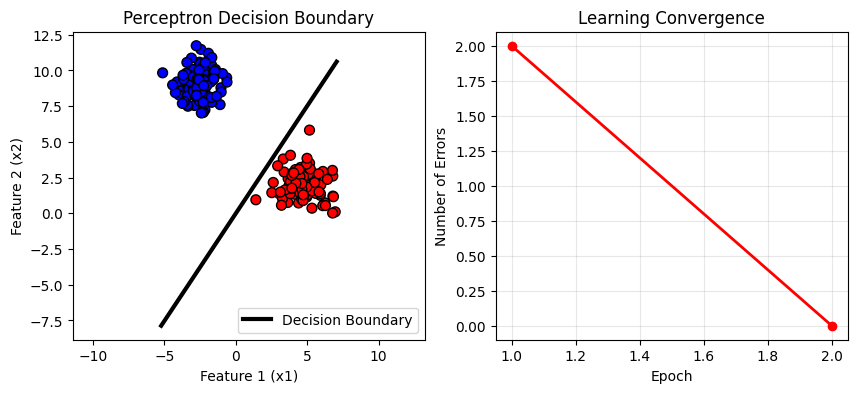


=== Perceptron Results ===
Weights: w = [0.1036, -0.0688]
Bias: b = 0.0000
Accuracy: 100.0%
Total epochs used: 2
Error history: [2, 0]


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class Perceptron:
    def __init__(self, lr=0.1, epochs=20):
        self.lr = lr
        self.epochs = epochs
        self.errors_history = []  

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        
        for epoch in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                linear_output = np.dot(xi, self.w) + self.b
                y_pred = 1 if linear_output >= 0 else -1

                if yi != y_pred:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1
            
            self.errors_history.append(errors)
            
            if errors == 0:
                print(f"Converged at epoch {epoch+1}")
                break
        
        return self

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.where(linear_output >= 0, 1, -1)

def plot_simple_decision_boundary(perceptron, X, y):
    """Simple boundary plot - just the line"""
    plt.figure(figsize=(10, 4))
    
    # Plot 1: Data points and decision boundary
    plt.subplot(1, 2, 1)
    
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', 
                edgecolors='k', s=50)
    
    w = perceptron.w
    b = perceptron.b
    
    x1_min, x1_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    x1_line = np.linspace(x1_min, x1_max, 100)
    
    if abs(w[1]) > 1e-10:  # Normal case
        x2_line = -(w[0] * x1_line + b) / w[1]
        plt.plot(x1_line, x2_line, 'k-', linewidth=3, label='Decision Boundary')
    elif abs(w[0]) > 1e-10:  # Vertical line case
        x2_line = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
        x1_line = np.full_like(x2_line, -b/w[0])
        plt.plot(x1_line, x2_line, 'k-', linewidth=3, label='Decision Boundary')
    else:  # Both weights are ~0 (uninitialized or degenerate)
        plt.axhline(y=0, color='k', linestyle='--', label='No decision (weights ~0)')
    
    plt.xlabel('Feature 1 (x1)')
    plt.ylabel('Feature 2 (x2)')
    plt.title('Perceptron Decision Boundary')
    plt.legend()
    plt.axis('equal')  
    
    # Plot 2: Error convergence
    plt.subplot(1, 2, 2)
    epochs_range = range(1, len(perceptron.errors_history) + 1)
    plt.plot(epochs_range, perceptron.errors_history, 'ro-', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Number of Errors')
    plt.title('Learning Convergence')
    plt.grid(True, alpha=0.3)
    
    plt.show()

if __name__ == "__main__":
    # Convert y from {0, 1} to {+1, -1} as make_blobs return in range {0, 1}
    y = np.where(y == 1, 1, -1)
    
    print(f"Dataset shape: {X.shape}")
    print(f"Unique labels: {np.unique(y)}")
    
    perceptron = Perceptron(lr=0.01, epochs=200) 
    perceptron.fit(X, y)
    
    plot_simple_decision_boundary(perceptron, X, y)
    
    predictions = perceptron.predict(X)
    accuracy = np.mean(predictions == y) * 100
    
    print(f"\n=== Perceptron Results ===")
    print(f"Weights: w = [{perceptron.w[0]:.4f}, {perceptron.w[1]:.4f}]")
    print(f"Bias: b = {perceptron.b:.4f}")
    print(f"Accuracy: {accuracy:.1f}%")
    print(f"Total epochs used: {len(perceptron.errors_history)}")
    print(f"Error history: {perceptron.errors_history}")